In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")
print(df.shape)
print(df.head())

(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


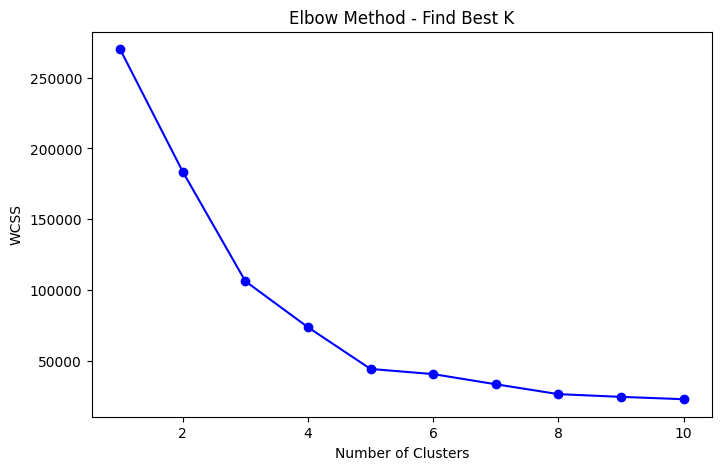

In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, 'bo-')
plt.title('Elbow Method - Find Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

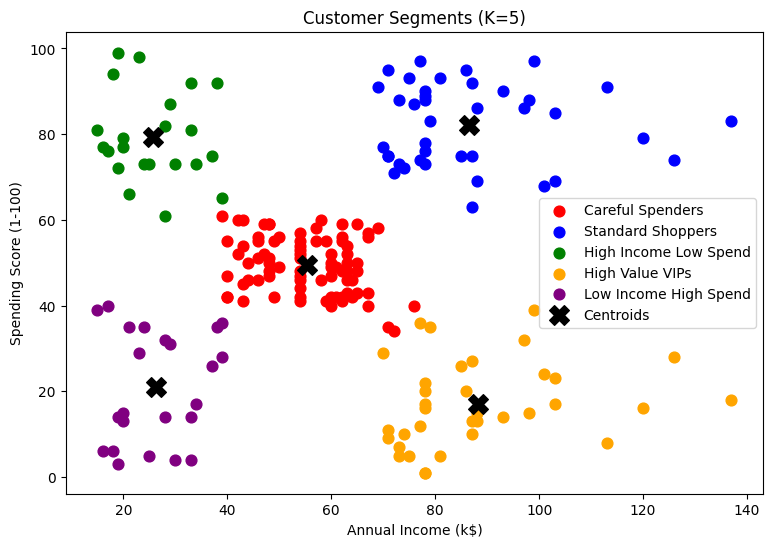

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      55.3                    49.5
1                      86.5                    82.1
2                      25.7                    79.4
3                      88.2                    17.1
4                      26.3                    20.9


In [ ]:
km = KMeans(n_clusters=5, init='k-means++', random_state=42)
df["Cluster"] = km.fit_predict(X)

colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Careful Spenders', 'Standard Shoppers',
          'High Income Low Spend', 'High Value VIPs',
          'Low Income High Spend']

plt.figure(figsize=(9, 6))
for i in range(5):
    plt.scatter(X[df["Cluster"]==i, 0],
                X[df["Cluster"]==i, 1],
                s=60, color=colors[i], label=labels[i])

plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            s=200, c='black', marker='X', label='Centroids')

plt.title('Customer Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

print(df.groupby("Cluster")[["Annual Income (k$)",
      "Spending Score (1-100)"]].mean().round(1))